In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
np.math=math
from scipy.integrate import odeint, solve_ivp
import pysindy as ps
import scienceplots
from pysindy.differentiation import FiniteDifference
plt.style.use('science')
plt.rcParams['font.size'] = 14

# Creación de Datos para SINDy

1.0225269255818796
1.151245


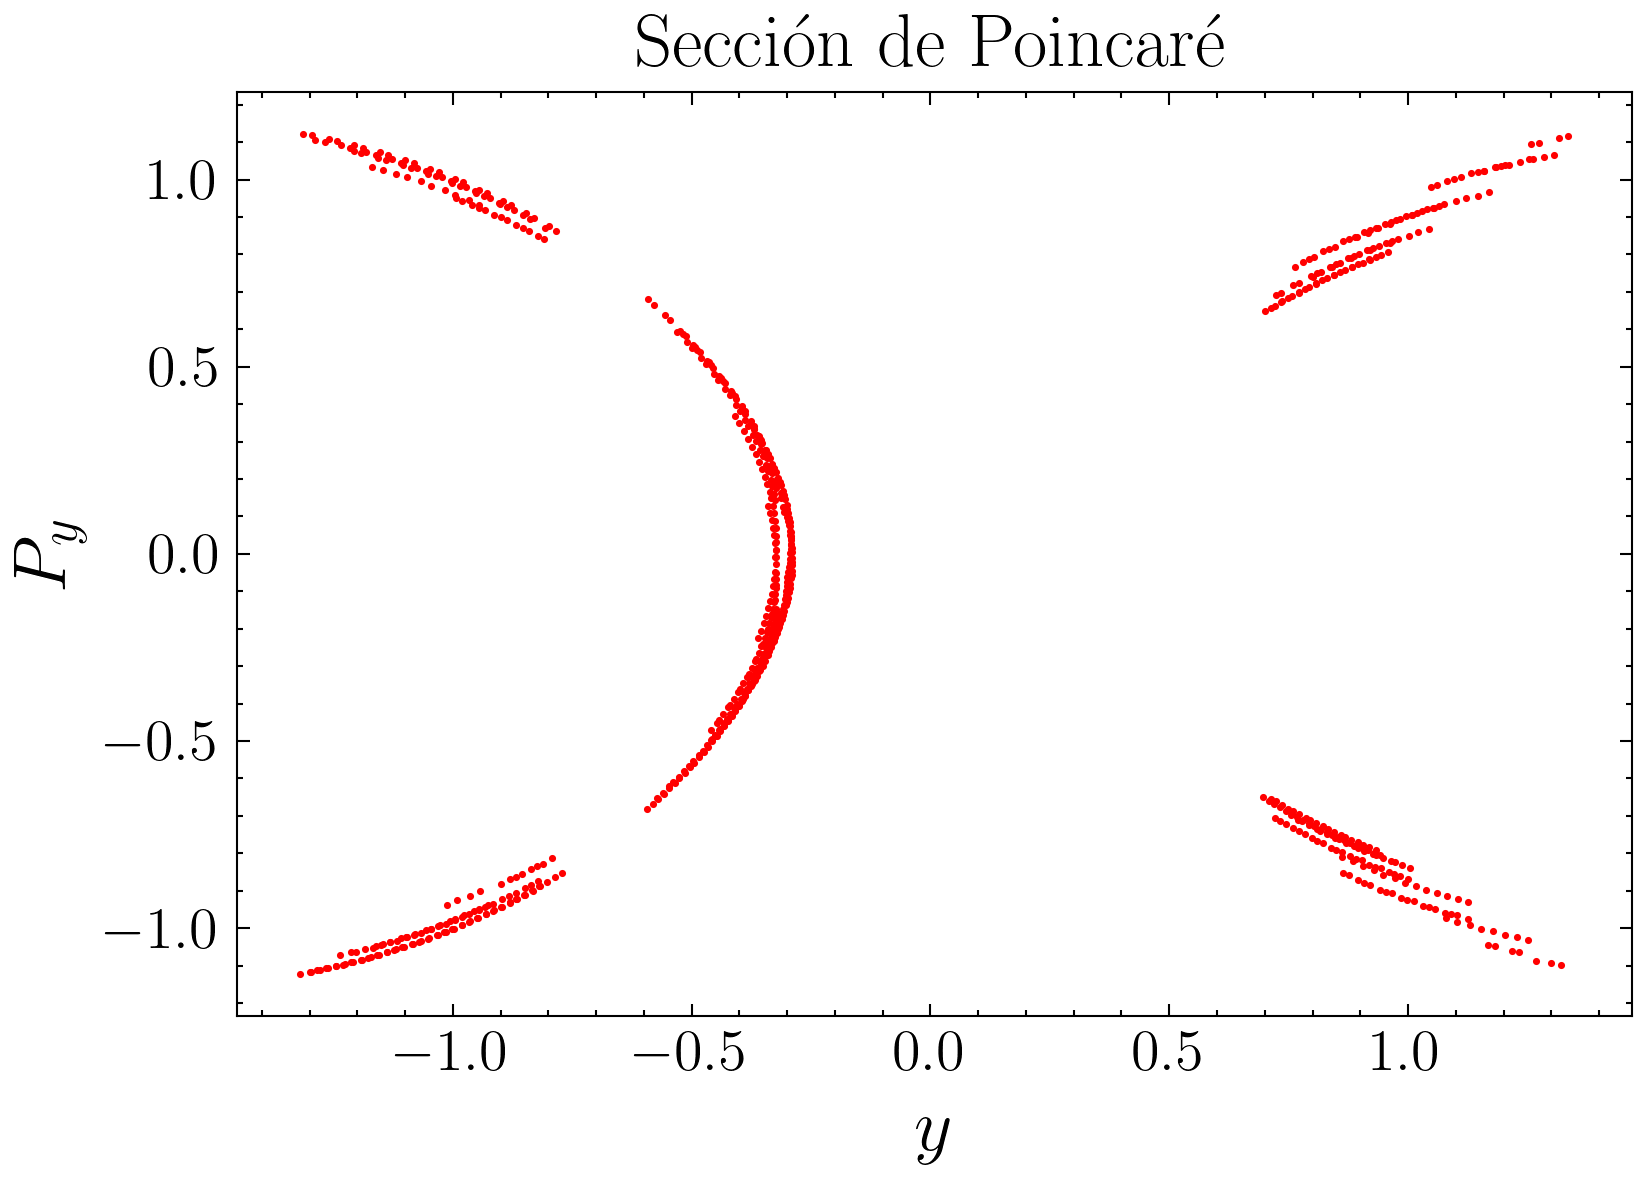

In [5]:
def safe_sqrt(x):
    return np.sqrt(np.clip(x, 0, None))

En = 2
beta = 1
alpha =1
a = 1
b=1
def hamilton_eqs(t, R):
    x, y, px, py = R
    dx_dt = px + beta*(y/2)
    dy_dt = py - beta*(x/2)
    dpx_dt = ((2*beta*py-beta**2*x)/2+((2*alpha*x+2*a*alpha)/((a**2+2*a*x+x**2+y**2)**(3/2)))+((2*alpha*x-2*alpha*a)/((a**2-2*a*x+x**2+y**2)**(3/2))))/2
    dpy_dt = ((-2*beta*px-y*beta**2)/2+((2*y*alpha)/((a**2-2*a*x+x**2+y**2)**(3/2)))+((2*y*alpha)/((a**2+2*a*x+x**2+y**2)**(3/2))))/2
    return [dx_dt, dy_dt, dpx_dt, dpy_dt]

plt.figure(figsize=(6, 4),dpi=300)
t_span=(0,500)
t_eval=np.linspace(t_span[0],t_span[1],10000)
discriminant=2*En-(b**2*(1.151245)**2)/4-4/safe_sqrt(1**2+(1.151245)**2)
print(safe_sqrt(discriminant))
initial_state=[0,1.151245,0,safe_sqrt(discriminant)]
sol = solve_ivp(hamilton_eqs, t_span, initial_state, method='RK45', t_eval=t_eval, rtol=1e-6, atol=1e-8)

poincare_y = []
poincare_py = []

for i in range(len(sol.t) - 1):
    if np.abs(sol.y[0, i]) < 1e-1 and sol.y[2, i] > 0:
        poincare_y.append(sol.y[1, i])
        poincare_py.append(sol.y[3, i])

if poincare_y:
    plt.scatter(poincare_y, poincare_py, s=0.5, color='r', label=f"y_0 = {initial_state[1]:.2f}")
print(initial_state[1])
plt.xlabel("$y$",fontsize=18)
plt.ylabel("$P_y$",fontsize=18)
plt.title(r"Sección de Poincaré",fontsize=18)
plt.show()

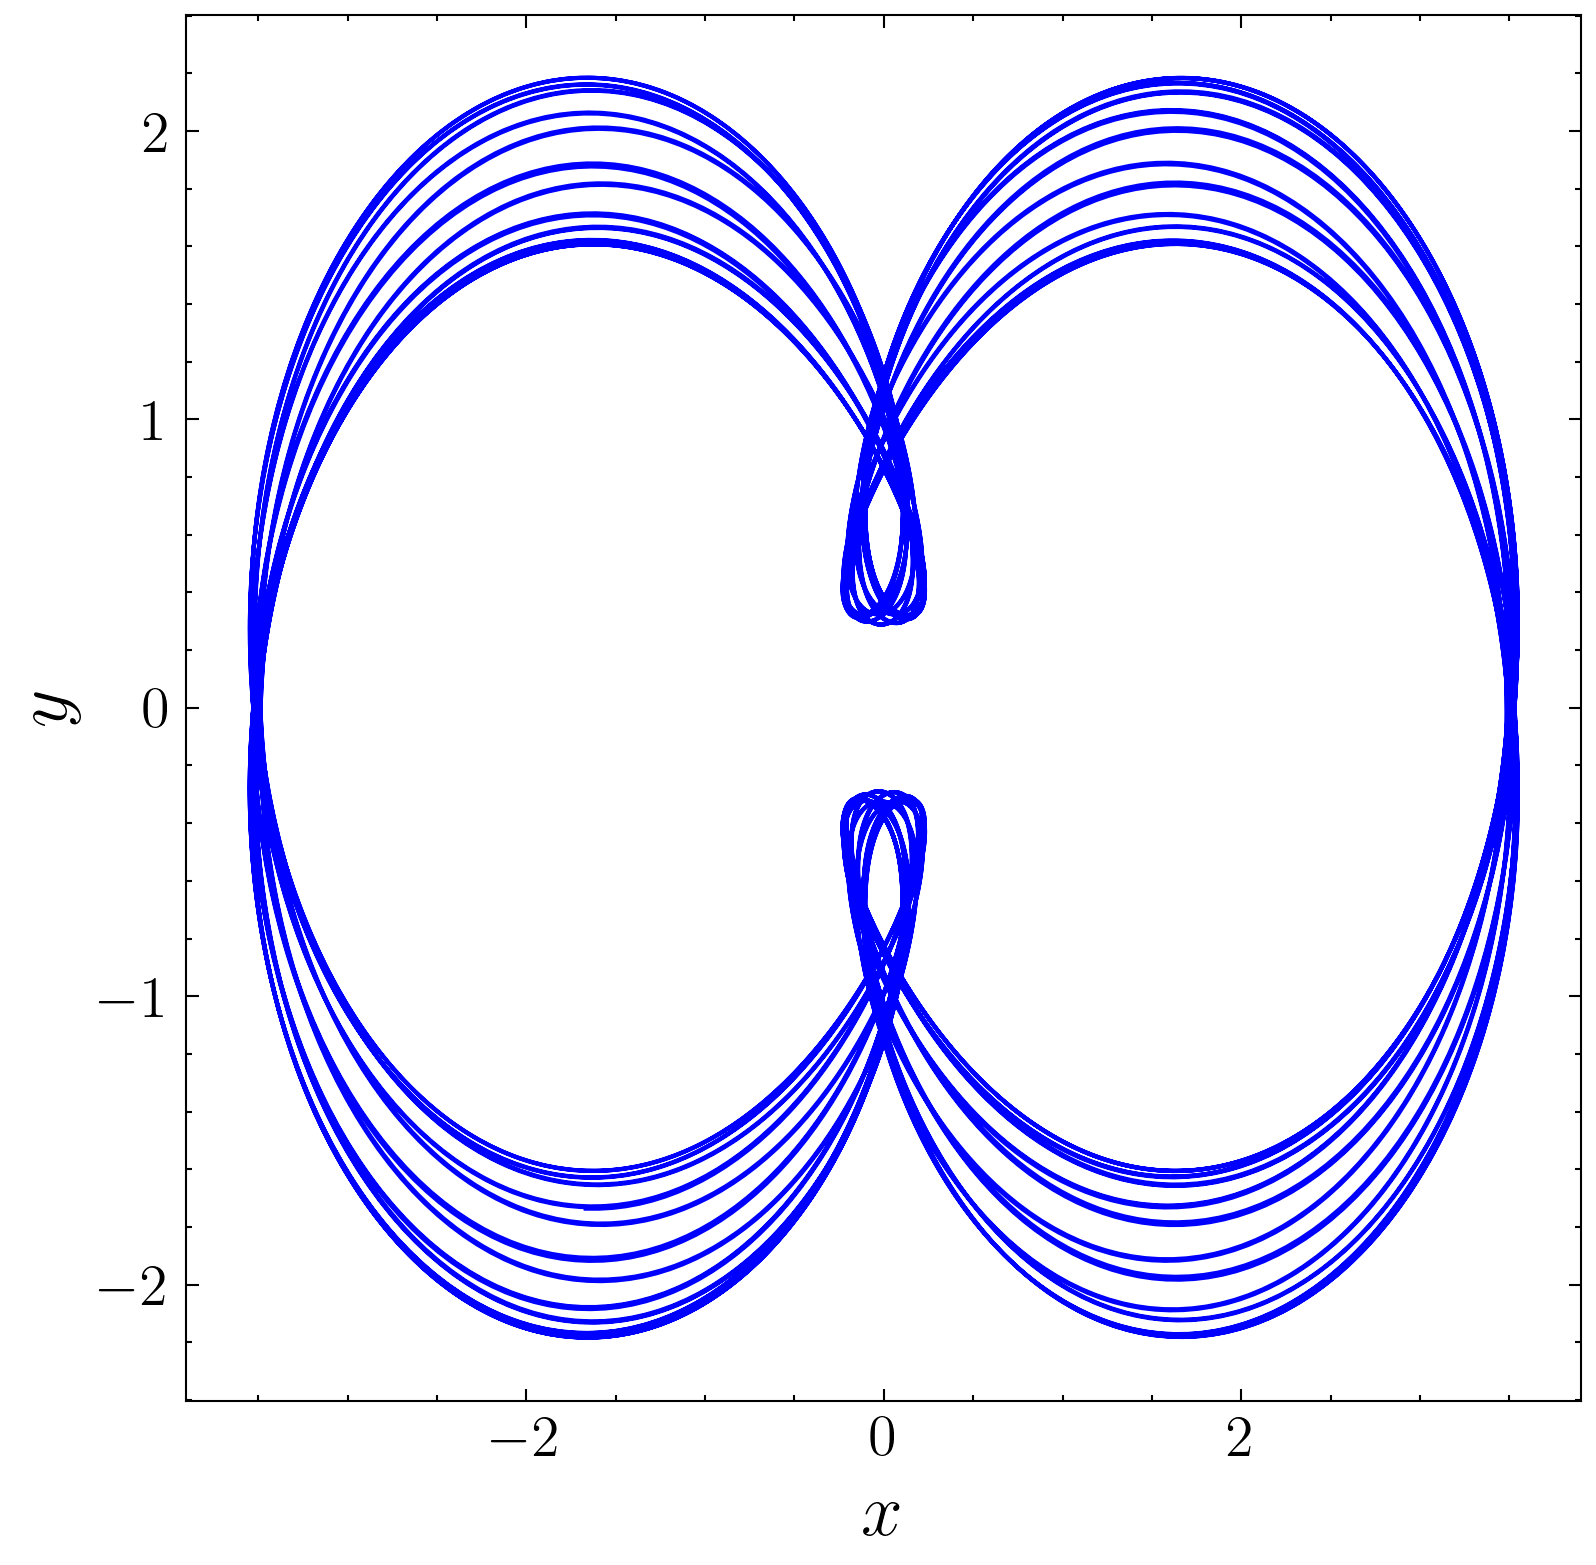

In [6]:
x_arr_test=[sol.y[0],sol.y[1],sol.y[2],sol.y[3]]
plt.figure(figsize=(6,6),dpi=300)
plt.plot(x_arr_test[0],x_arr_test[1],'b-')
plt.xlabel(r"$x$",fontsize=18)
plt.ylabel(r"$y$",fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

C:\Users\MEGQ_\AppData\Local\Temp\ipykernel_13088\3185590788.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


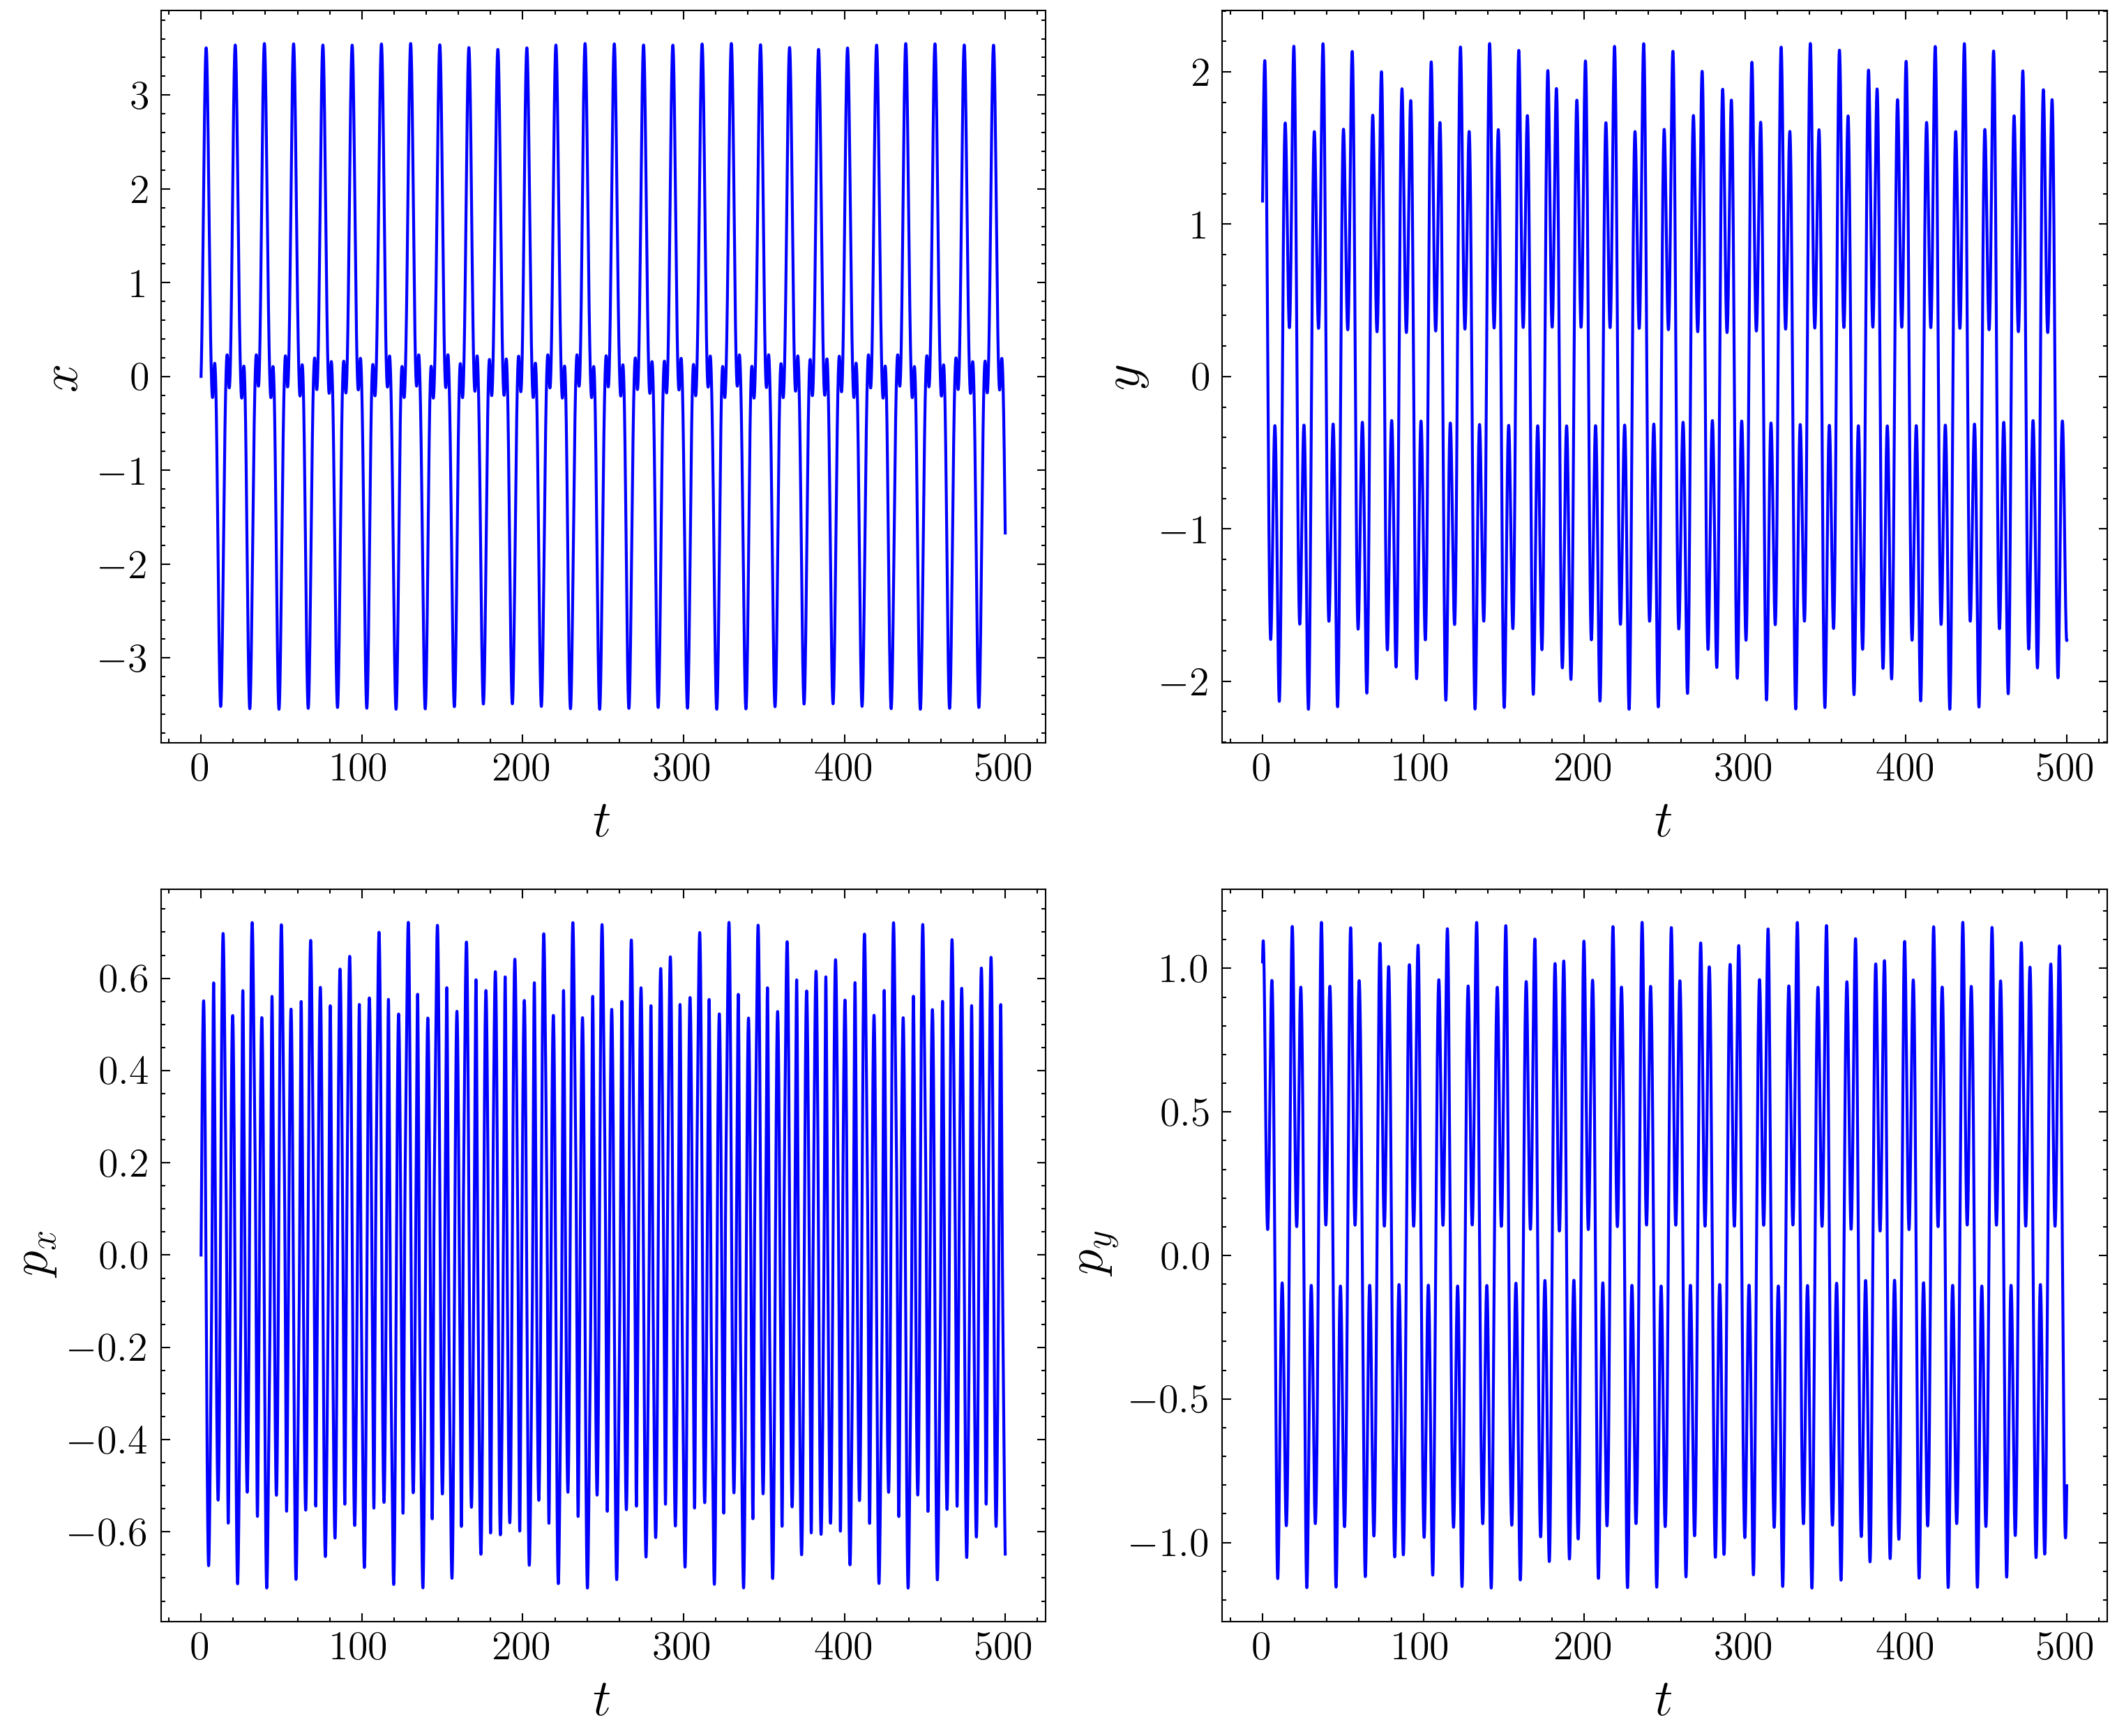

In [7]:
def safe_sqrt(x):
    return np.sqrt(np.clip(x, 0, None))

En = 2
beta = 1
alpha =1
a = 1

def hamilton_eqs(R,t):#Ecuaciones de Movimiento
    x, y, px, py = R
    dRdt=[px + beta*(y/2)
          ,py - beta*(x/2)
          ,((2*beta*py-beta**2*x)/2+((2*alpha*x+2*a*alpha)/((a**2+2*a*x+x**2+y**2)**(3/2)))+((2*alpha*x-2*alpha*a)/((a**2-2*a*x+x**2+y**2)**(3/2))))/2
          ,((-2*beta*px-y*beta**2)/2+((2*y*alpha)/((a**2-2*a*x+x**2+y**2)**(3/2)))+((2*y*alpha)/((a**2+2*a*x+x**2+y**2)**(3/2))))/2
          ]
    return dRdt

def coefficients(self):
    check_is_fitted(self, "model")
    return self.model.steps[-1][1].coef_

dt=0.005
k=1
t = np.arange(0, 500, dt)
x_arr_mine = odeint(hamilton_eqs,initial_state,t)
print('===========================================')
#Gráficas de series temporales#############   
fig, axs = plt.subplots(2, 2, figsize=(12, 10),dpi=300)
axs[0, 0].plot(t, x_arr_mine[:,0], "b")
axs[0, 0].set_xlabel(r"$t$",fontsize=18)
axs[0, 0].set_ylabel(r"$x$",fontsize=18)
axs[0, 1].plot(t, x_arr_mine[:,1], "b")
axs[0, 1].set_xlabel(r"$t$",fontsize=18)
axs[0, 1].set_ylabel(r"$y$",fontsize=18)
axs[1, 0].plot(t, x_arr_mine[:,2], "b")
axs[1, 0].set_xlabel(r"$t$",fontsize=18)
axs[1, 0].set_ylabel(r"$p_x$",fontsize=18)
axs[1, 1].plot(t, x_arr_mine[:,3], "b")
axs[1, 1].set_xlabel(r"$t$",fontsize=18)
axs[1, 1].set_ylabel(r"$p_y$",fontsize=18)
fig.show()

## SINDy

In [75]:
########Calculo de Derivadas##############
fd = FiniteDifference(order=2, drop_endpoints=True)
dx_arr_mine = fd._differentiate(x_arr_mine, t=dt) # Still pass dt
##############CREAR LIBRERIA DE FUNCIONES#####################
a = 1.0  # valor de a en tu sistema

def coulomb_fx(x, y):
    r1 = ((x - a)**2 + y**2)**(3/2)
    r2 = ((x + a)**2 + y**2)**(3/2)
    return (x - a)/r1 + (x + a)/r2

def coulomb_fy(x, y):
    r1 = ((x - a)**2 + y**2)**(3/2)
    r2 = ((x + a)**2 + y**2)**(3/2)
    return y * (1/r1 + 1/r2)
def name_fx(*vars):
    return "F_x"

def name_fy(*vars):
    return "F_y"

custom_lib = ps.CustomLibrary(library_functions=[coulomb_fx, coulomb_fy],function_names=[name_fx,name_fy])

library = ps.GeneralizedLibrary([ps.PolynomialLibrary(degree=4, include_interaction=True),custom_lib])

##########SINDy###############
threshold =0.01
model = ps.SINDy(optimizer=ps.STLSQ(threshold=threshold),
                 feature_library=library,
                 differentiation_method=fd) # Pass the differentiation method here
model.fit(x_arr_mine, t=dt) # Also important to pass dt here

#############Coeficientes del modelo de ajuste#################
coef = model.coefficients()
print(coef[:, :])
print('===========================================')
model.print()
print('===========================================')

[[ 0.          0.          0.50000041  0.99999046  0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.         -0.49999828  0.          0.          0.9999946   0.
   0.          0.        

C:\Users\MEGQ_\AppData\Local\Temp\ipykernel_13088\2219385008.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


-------------------------------------------------------
azul= Solucion con ecuaciones de movimiento originales
rojo= Solucion con ecuaciones de movimiento de SINDy


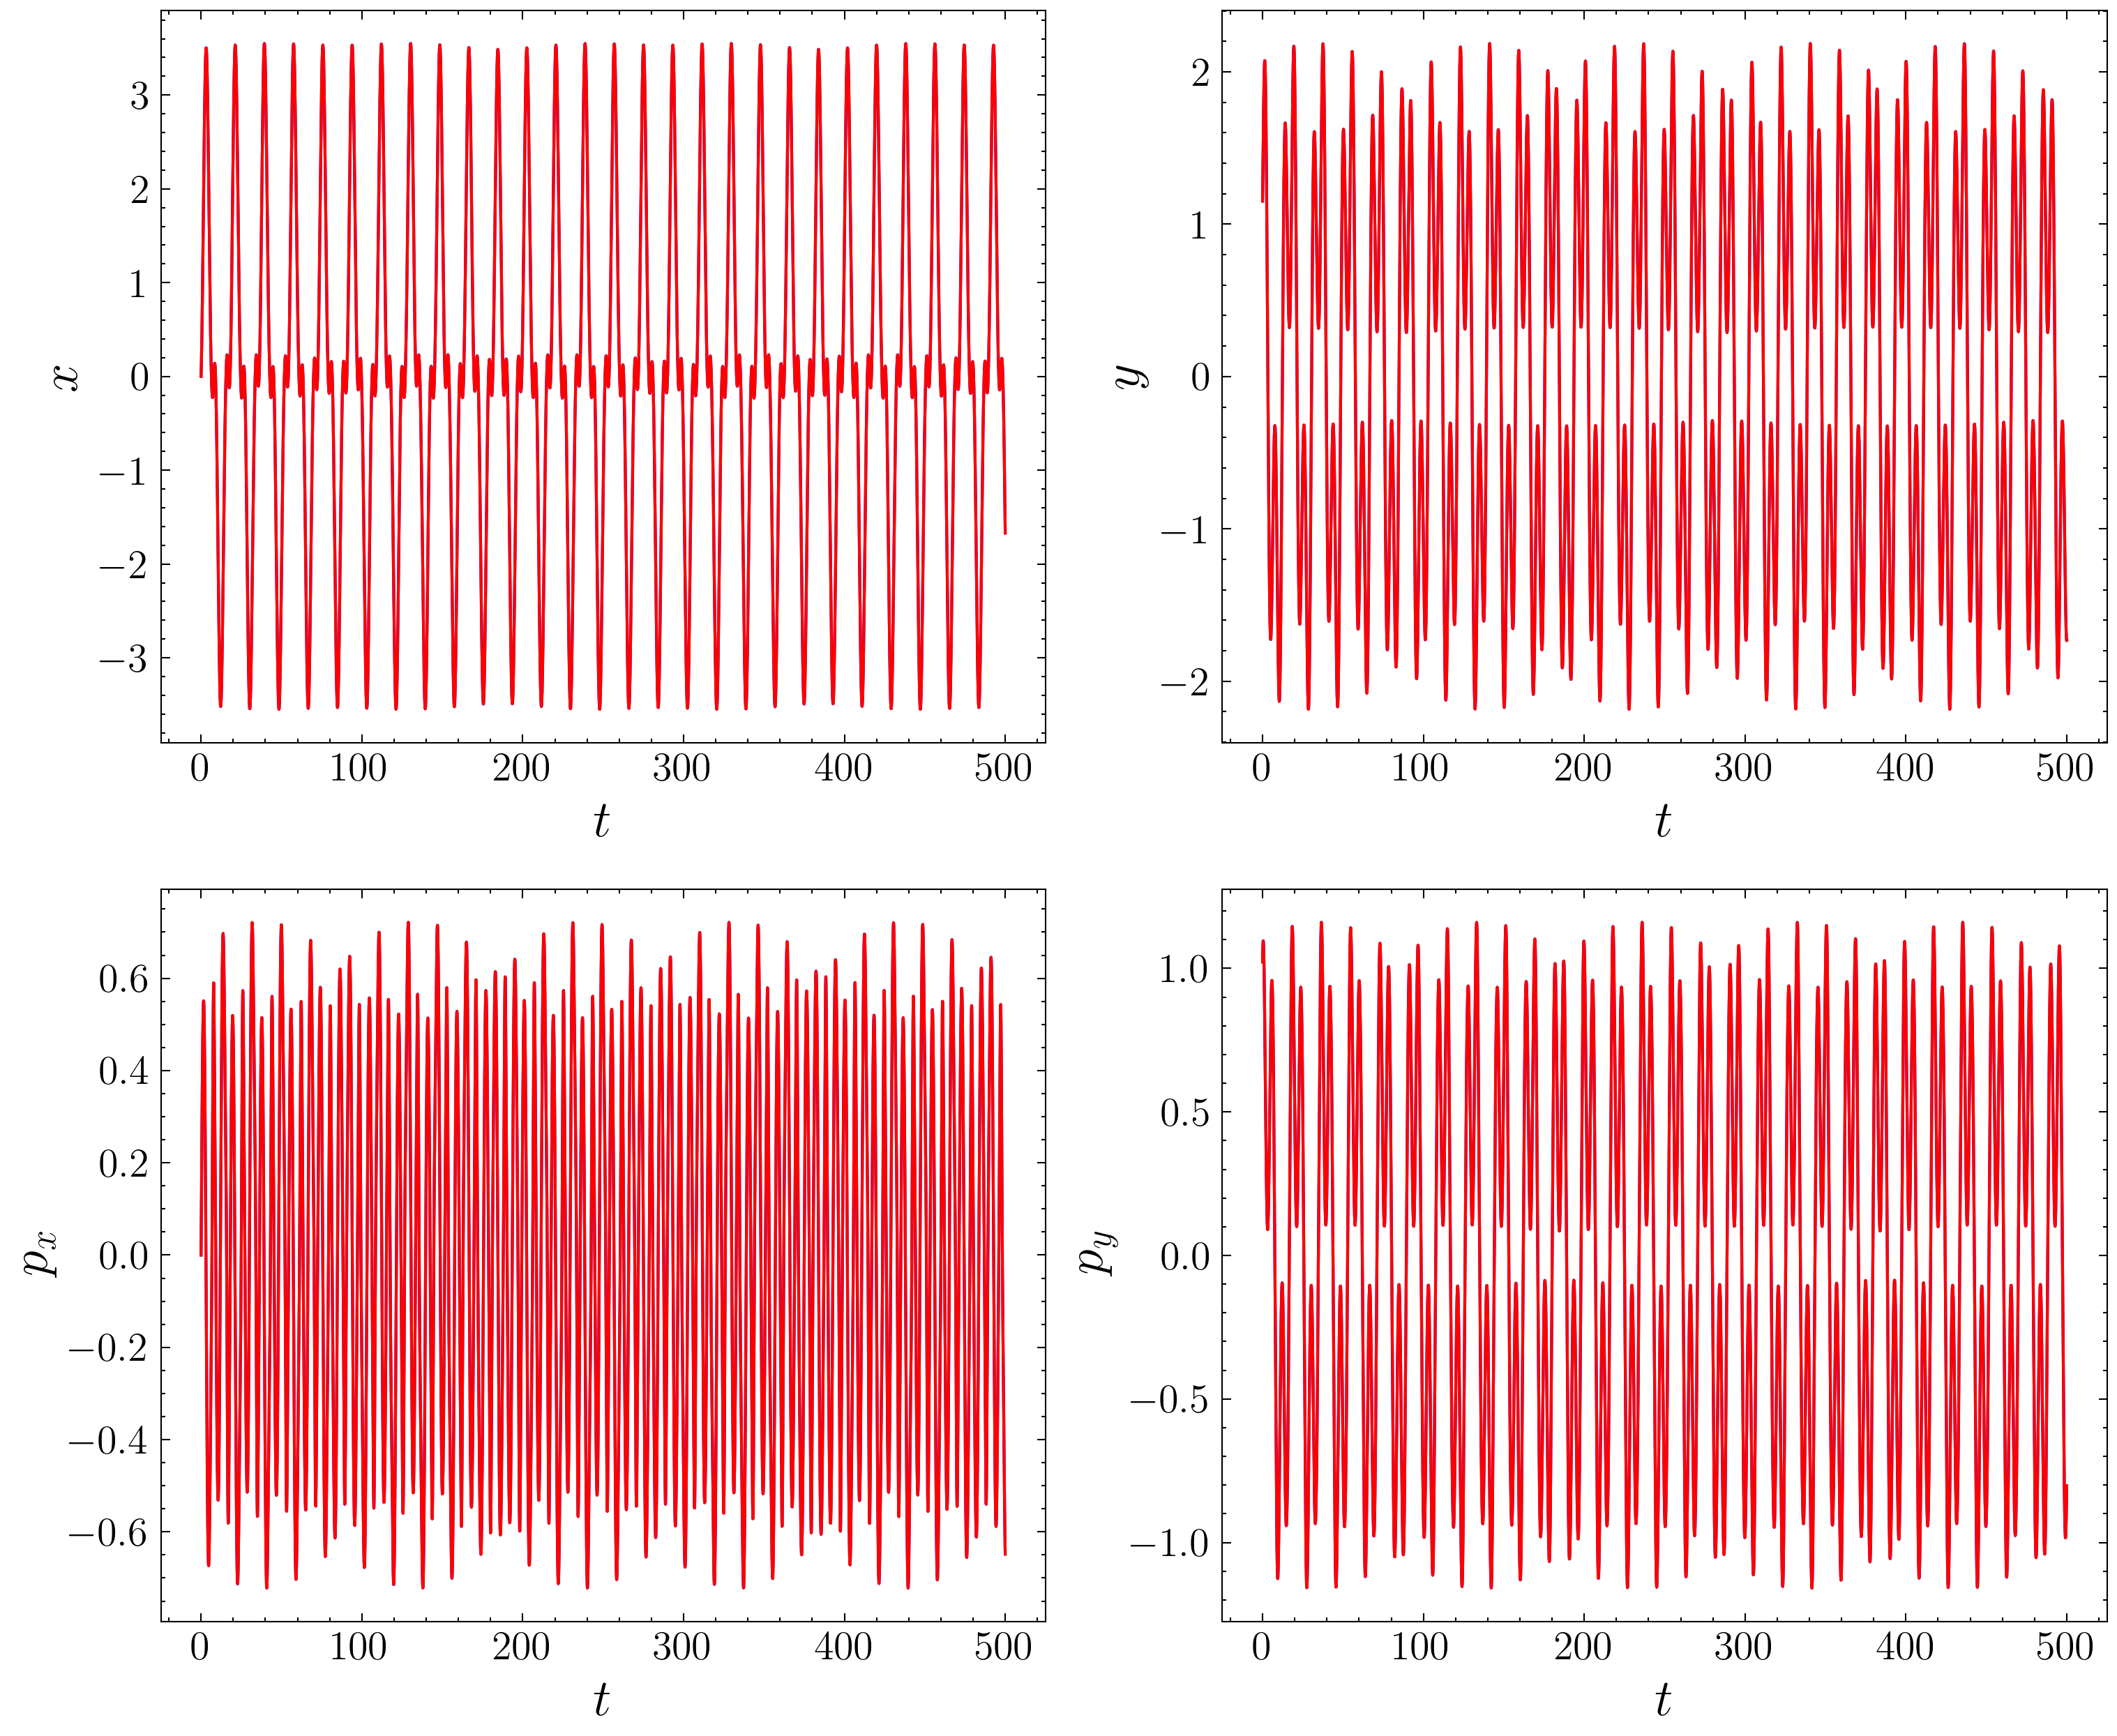

In [8]:
#MODELO SINDY
def eomSINDY(R,t):
    x0,x1,x2,x3=R
    dRdt=[0.5*x1+x2,
          x3-0.5*x0,
          -0.250*x0 + 0.500*x3 +(x0 - a)/(((x0 - a)**2 + x1**2)**(3/2)) + ((x0 + a)/(((x0 + a)**2 + x1**2)**(3/2))),
          -0.250*x1 + -0.500*x2 +x1*(1/(((x0 - a)**2 + x1**2)**(3/2)) + 1/(((x0 + a)**2 + x1**2)**(3/2)))
        ]
    return dRdt
x_arr_sindy = odeint(eomSINDY, initial_state, t)
fig, axs = plt.subplots(2, 2, figsize=(12, 10),dpi=300)
axs[0, 0].plot(t, x_arr_mine[:, 0], "b")
axs[0, 0].plot(t, x_arr_sindy[:, 0], "r")
axs[0, 0].set_xlabel(r"$t$",fontsize=18)
axs[0, 0].set_ylabel(r"$x$",fontsize=18)
axs[0, 1].plot(t, x_arr_mine[:, 1], "b")
axs[0, 1].plot(t, x_arr_sindy[:, 1], "r")
axs[0, 1].set_xlabel(r"$t$",fontsize=18)
axs[0, 1].set_ylabel(r"$y$",fontsize=18)
axs[1, 0].plot(t, x_arr_mine[:, 2], "b")
axs[1, 0].plot(t, x_arr_sindy[:, 2], "r")
axs[1, 0].set_xlabel(r"$t$",fontsize=18)
axs[1, 0].set_ylabel(r"$p_x$",fontsize=18)
axs[1, 1].plot(t, x_arr_mine[:, 3], "b")
axs[1, 1].plot(t, x_arr_sindy[:, 3], "r")
axs[1, 1].set_xlabel(r"$t$",fontsize=18)
axs[1, 1].set_ylabel(r"$p_y$",fontsize=18)
fig.show()
print('-------------------------------------------------------')
print('azul= Solucion con ecuaciones de movimiento originales')
print('rojo= Solucion con ecuaciones de movimiento de SINDy')


C:\Users\MEGQ_\AppData\Local\Temp\ipykernel_13088\982592735.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


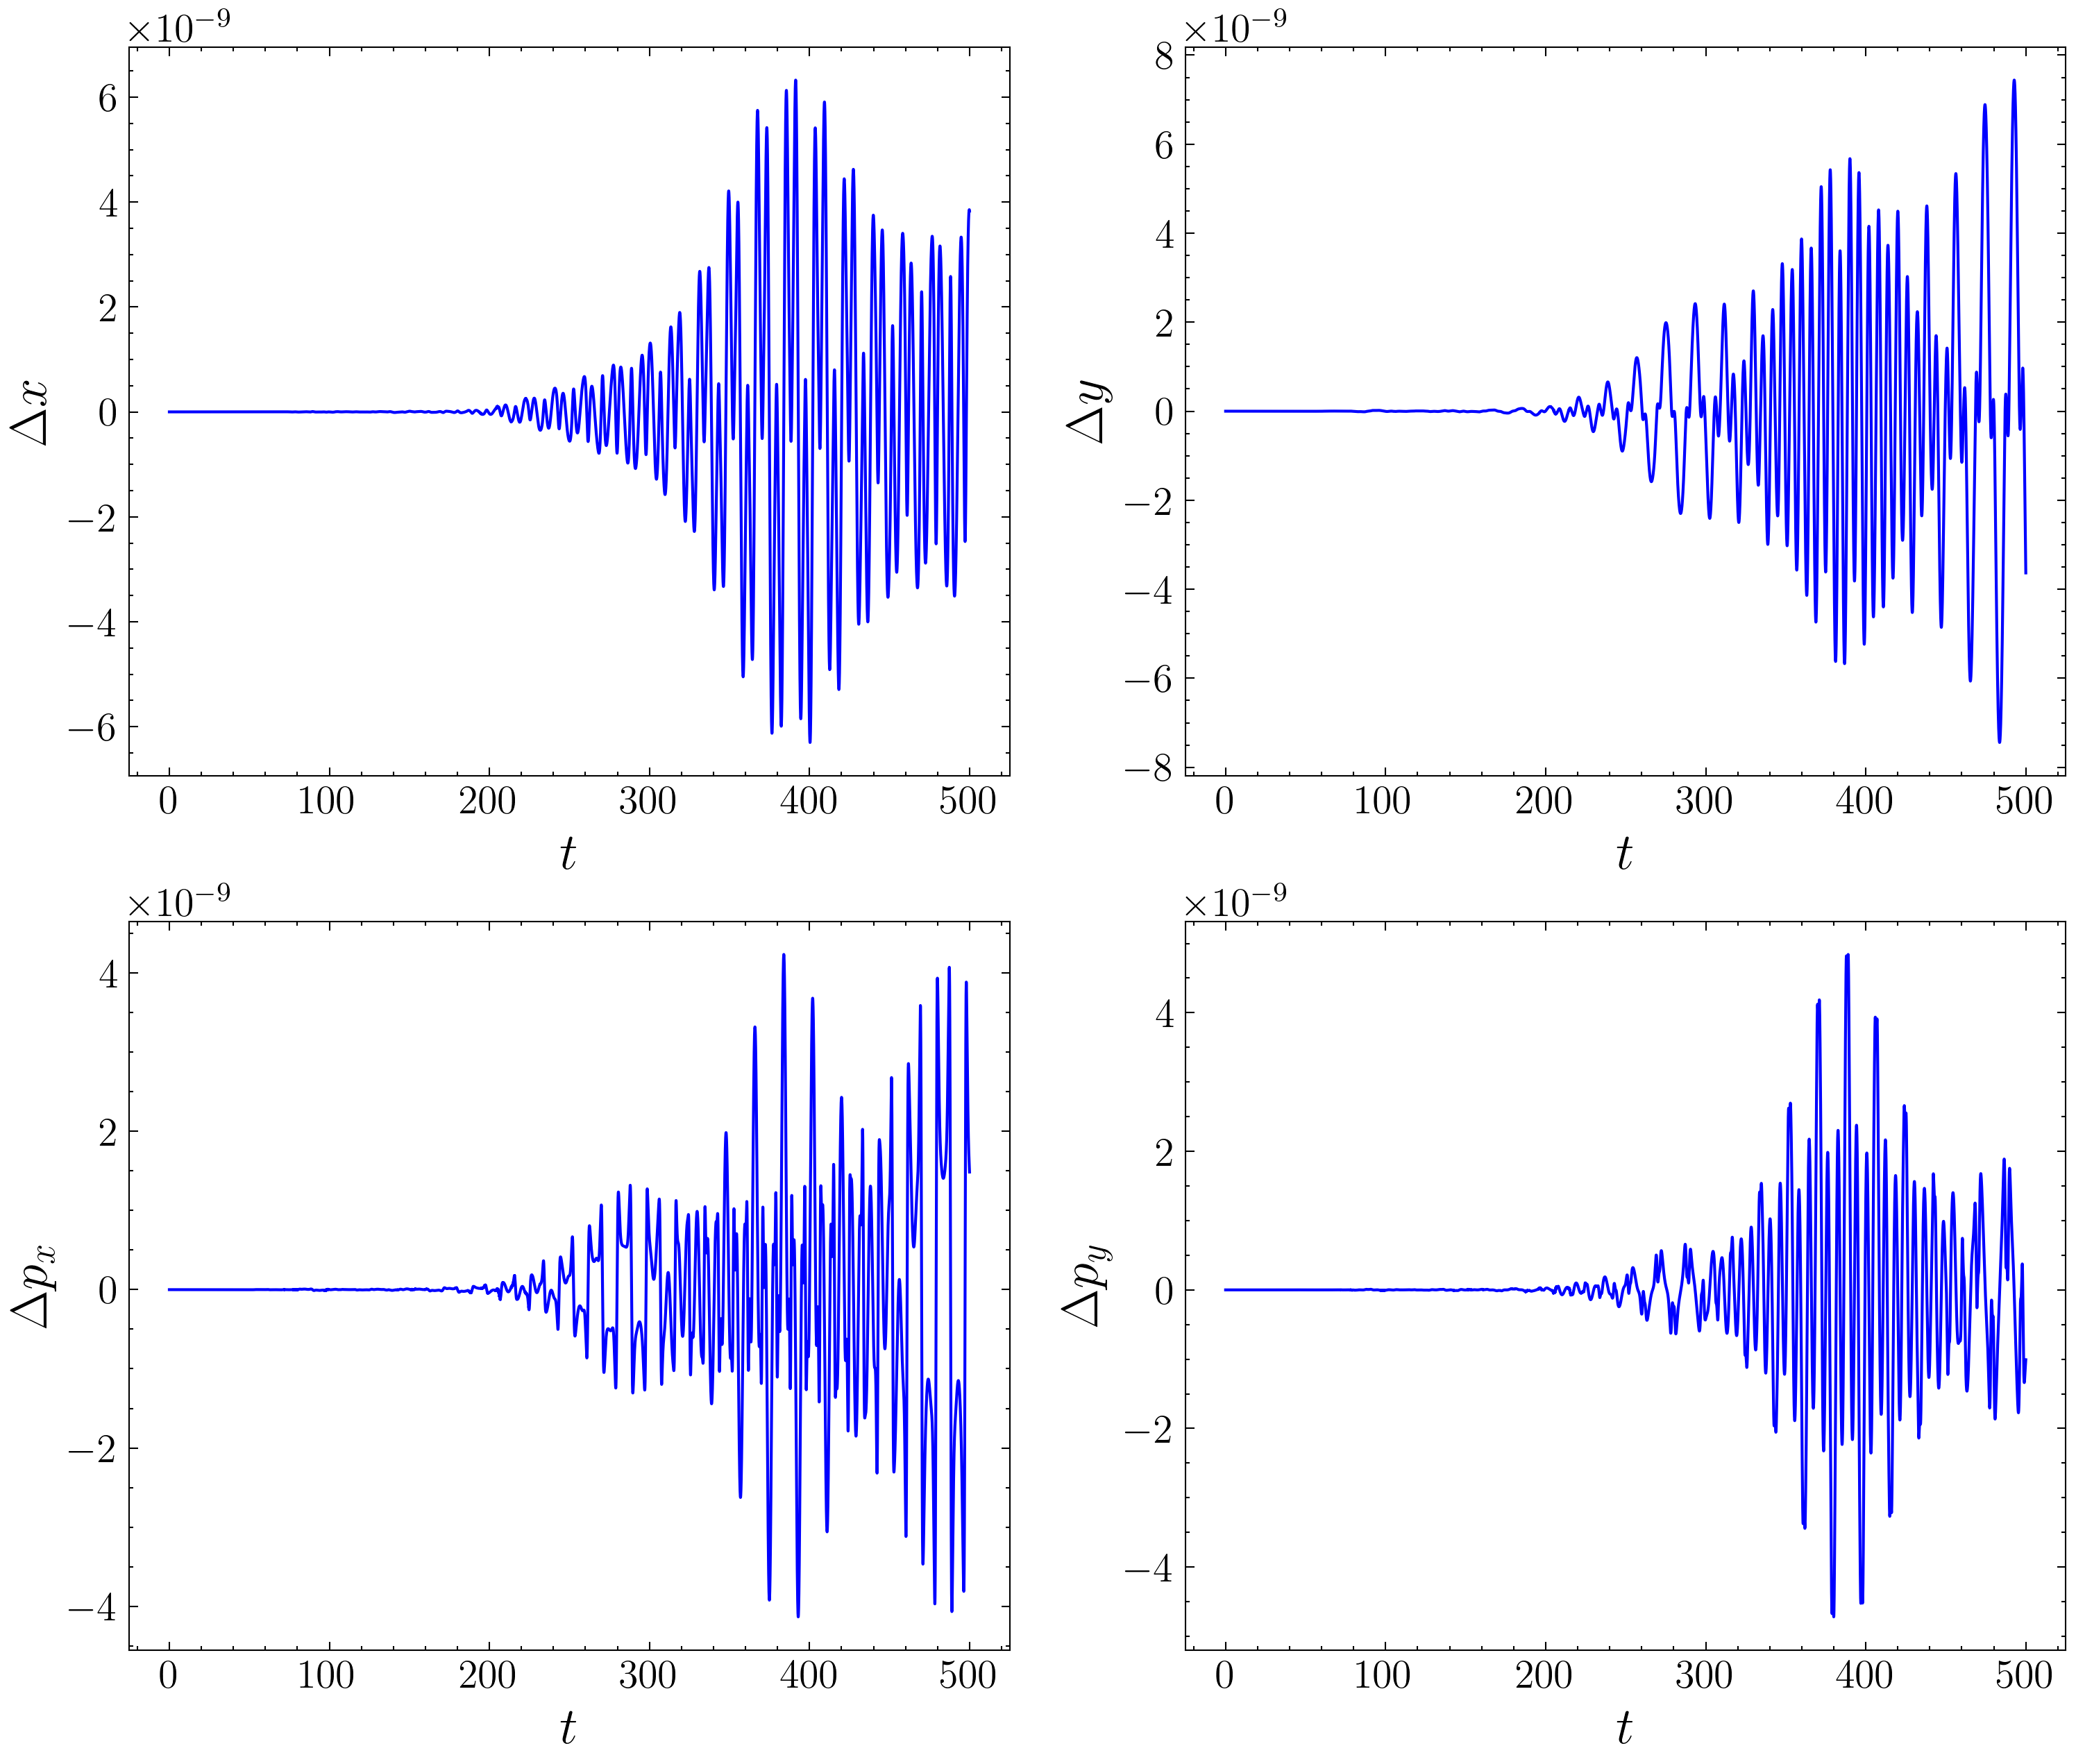

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10),dpi=300)
axs[0, 0].plot(t, x_arr_sindy[:, 0]-x_arr_mine[:, 0], "b")
axs[0, 0].set_xlabel(r"$t$",fontsize=18)
axs[0, 0].set_ylabel(r"$\Delta x$",fontsize=18)
axs[0, 1].plot(t, x_arr_sindy[:, 1]-x_arr_mine[:, 1], "b")
axs[0, 1].set_xlabel(r"$t$",fontsize=18)
axs[0, 1].set_ylabel(r"$\Delta y$",fontsize=18)
axs[1, 0].plot(t, x_arr_sindy[:, 2]-x_arr_mine[:, 2], "b")
axs[1, 0].set_xlabel(r"$t$",fontsize=18)
axs[1, 0].set_ylabel(r"$\Delta p_x$",fontsize=18)
axs[1, 1].plot(t, x_arr_sindy[:, 3]-x_arr_mine[:, 3], "b")
axs[1, 1].set_xlabel(r"$t$",fontsize=18)
axs[1, 1].set_ylabel(r"$\Delta p_y$",fontsize=18)
fig.show()

C:\Users\MEGQ_\AppData\Local\Temp\ipykernel_13088\2215600464.py:3: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot(x_arr_sindy[:,0],x_arr_sindy[:,1],'r--',linestyle=(0,(10,10)),label='SINDy')


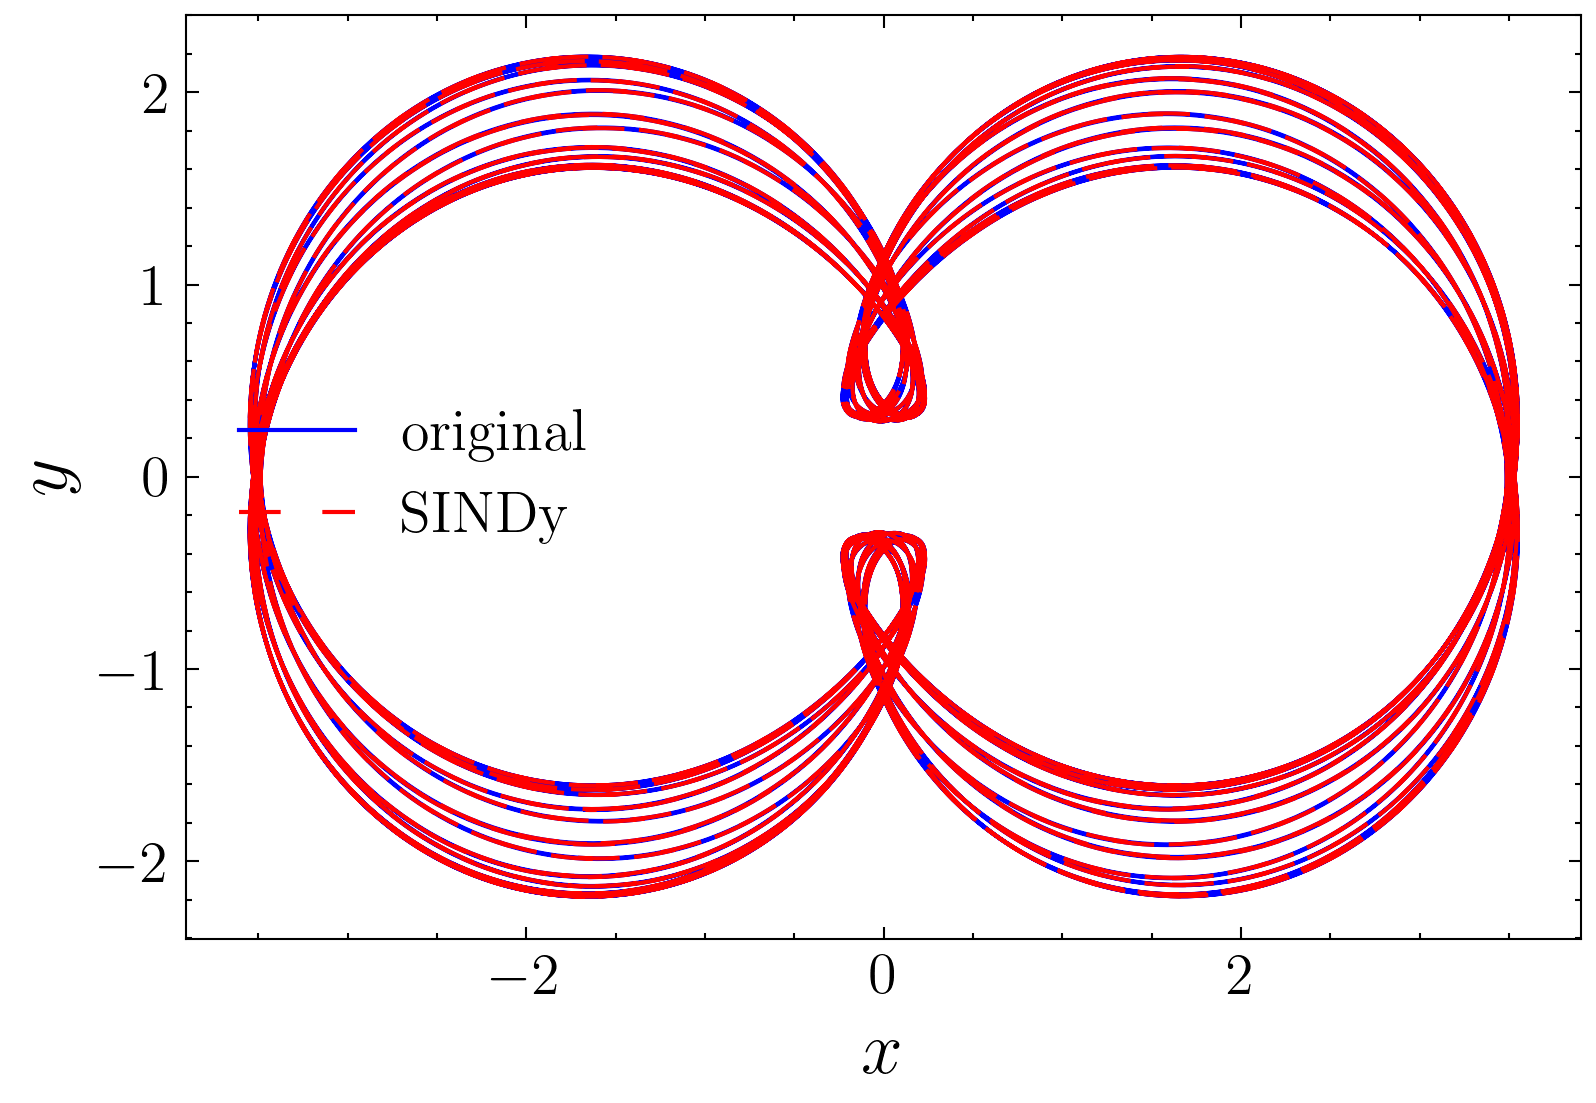

In [11]:
plt.figure(figsize=(6,4),dpi=300)
plt.plot(x_arr_mine[:,0],x_arr_mine[:,1],'b-',label='original')
plt.plot(x_arr_sindy[:,0],x_arr_sindy[:,1],'r--',linestyle=(0,(10,10)),label='SINDy')
plt.xlabel(r'$x$',fontsize=18)
plt.ylabel(r'$y$',fontsize=18)
plt.legend()
plt.show()

## Error relativo de los coeficientes de SINDy al variar $dt$

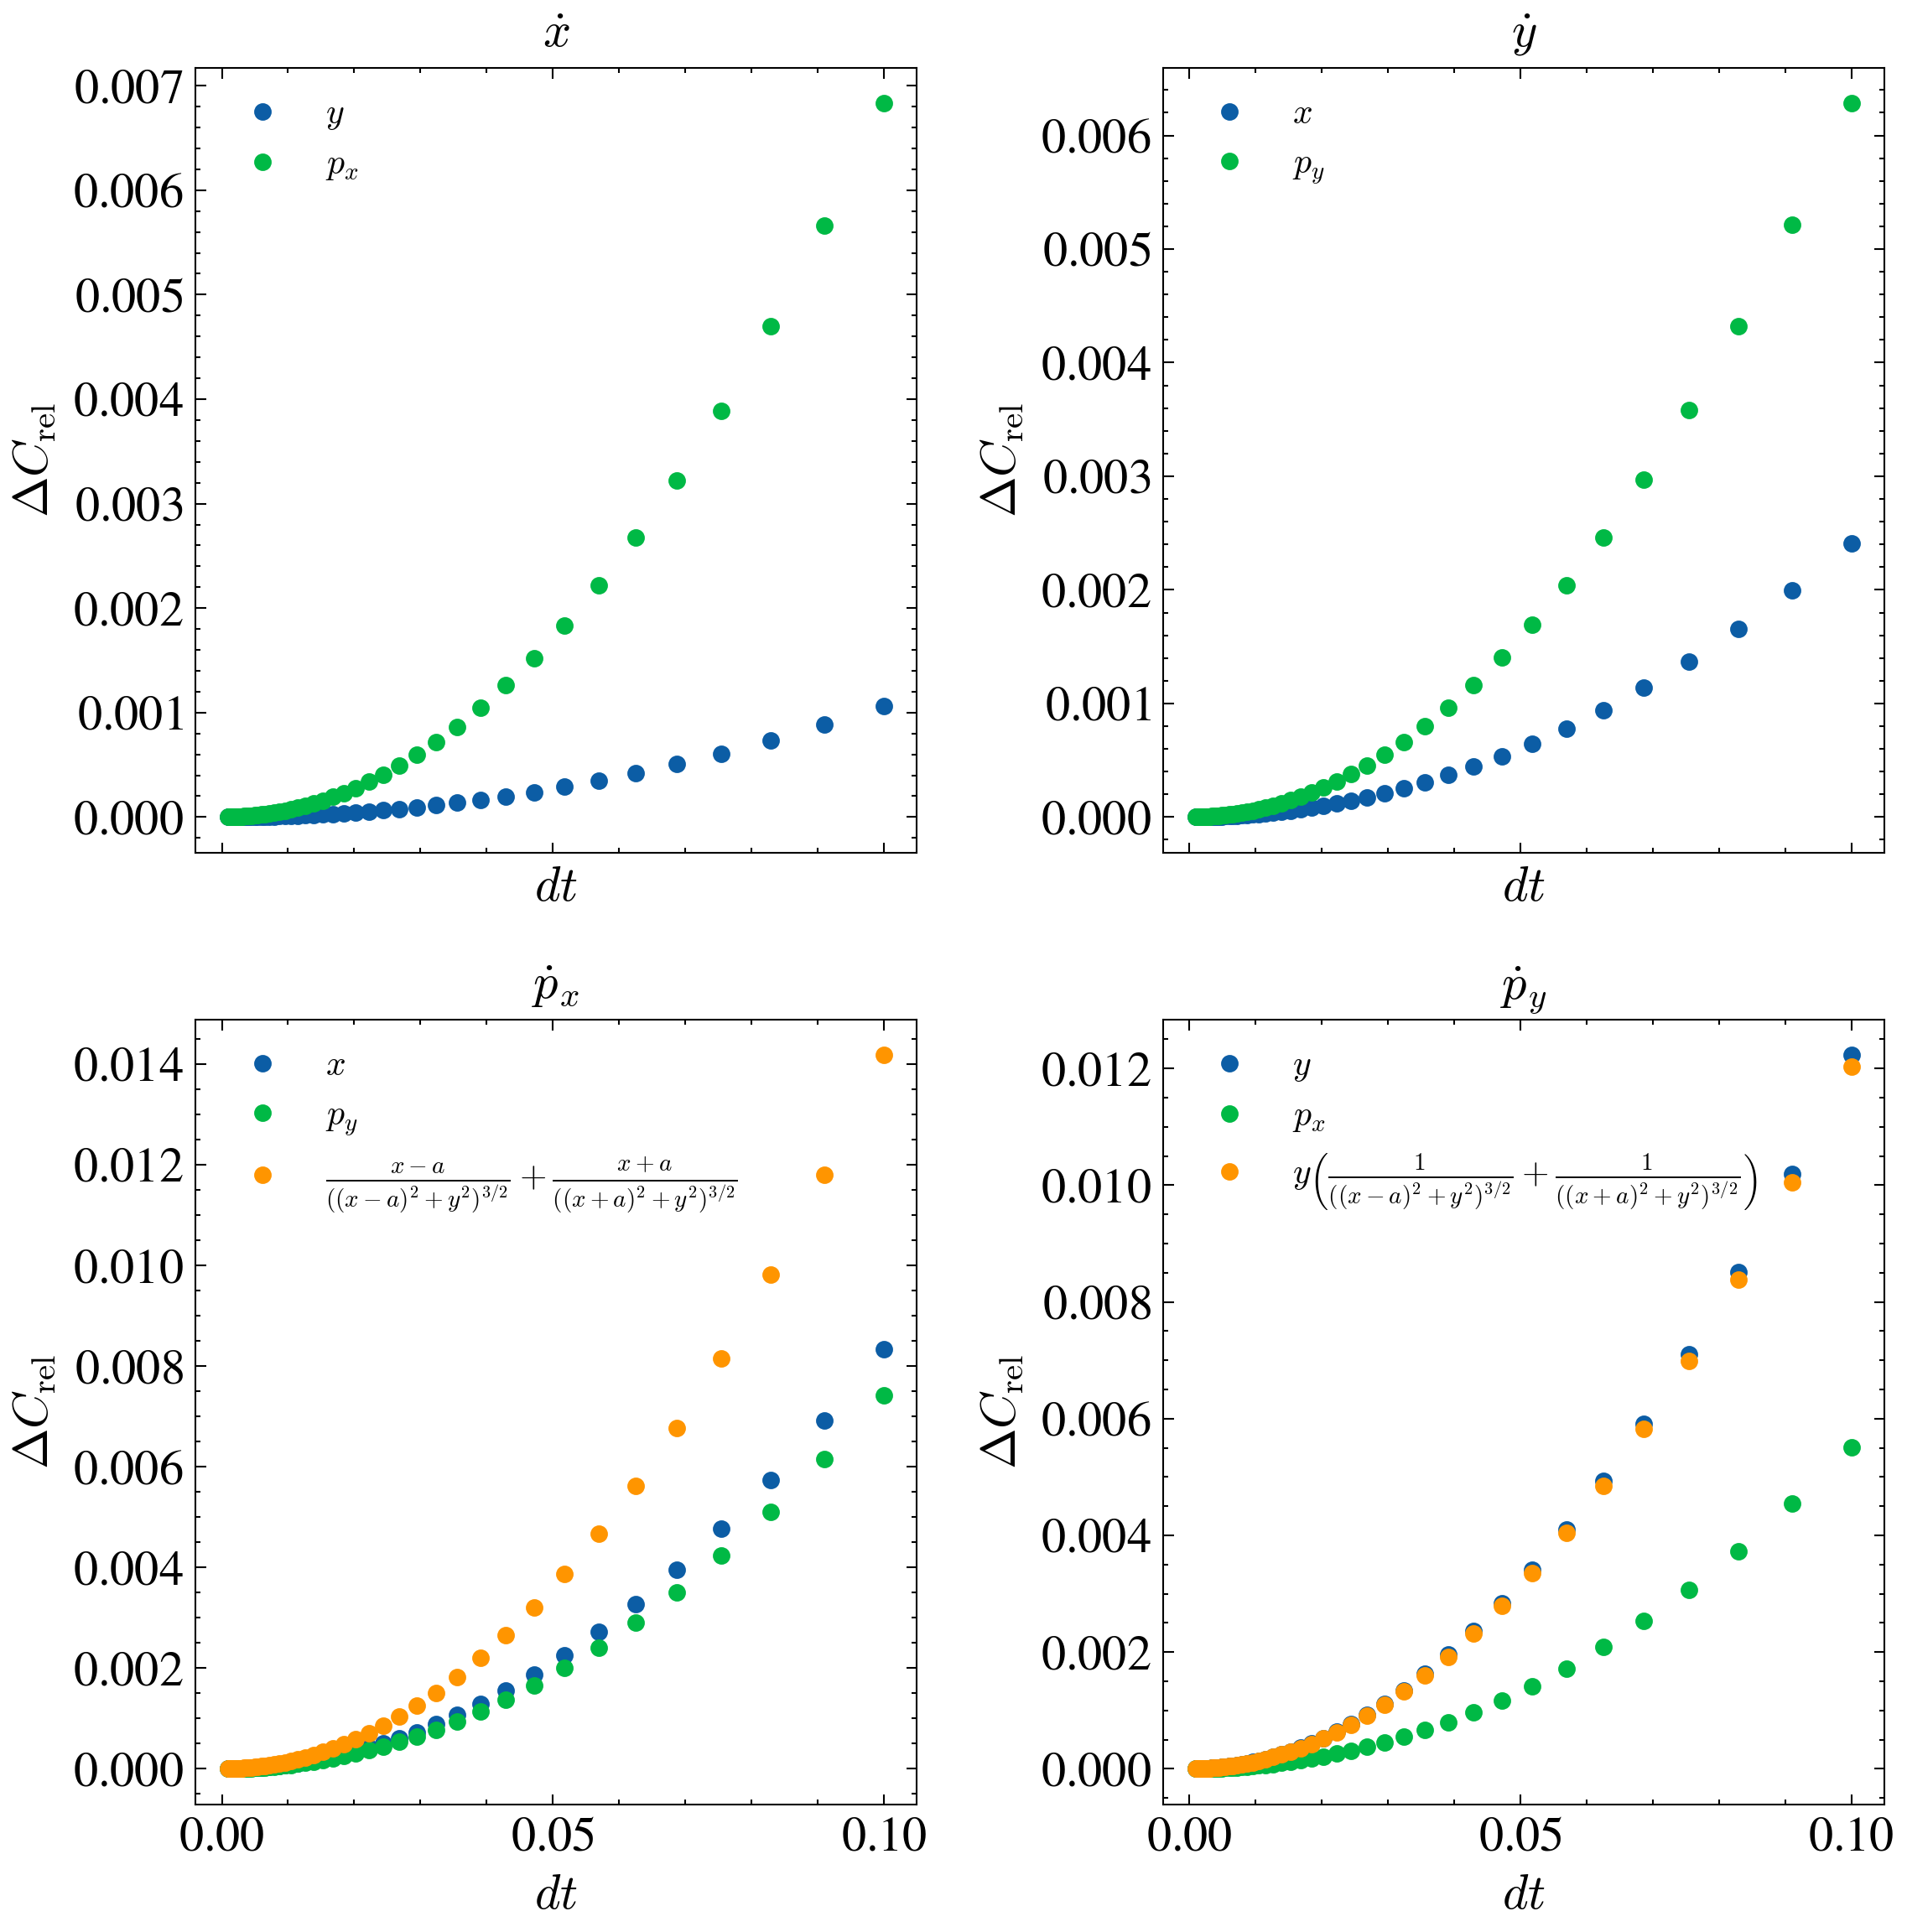

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
plt.style.use(['science','no-latex'])
# =====================================================
# Sistema
# =====================================================
beta = 1
alpha = 1
a = 1

def hamilton_eqs(t, R):
    x, y, px, py = R

    dx_dt = px + beta * y / 2
    dy_dt = py - beta * x / 2

    dpx_dt = (
        (2 * beta * py - beta**2 * x) / 2
        + alpha * (
            ((x + a) / ((x + a)**2 + y**2)**(3/2))
            + ((x - a) / ((x - a)**2 + y**2)**(3/2))
        )
    )

    dpy_dt = (
        (-2 * beta * px - beta**2 * y) / 2
        + alpha * y * (
            1 / ((x - a)**2 + y**2)**(3/2)
            + 1 / ((x + a)**2 + y**2)**(3/2)
        )
    )

    return [dx_dt, dy_dt, dpx_dt, dpy_dt]

# =====================================================
# Librería SINDy
# =====================================================
def coulomb_fx(x, y, px, py):
    r1 = ((x - a)**2 + y**2)**(3/2)
    r2 = ((x + a)**2 + y**2)**(3/2)
    return (x - a)/r1 + (x + a)/r2

def coulomb_fy(x, y, px, py):
    r1 = ((x - a)**2 + y**2)**(3/2)
    r2 = ((x + a)**2 + y**2)**(3/2)
    return y * (1/r1 + 1/r2)

def name_fx(*vars):
    return "F_x"

def name_fy(*vars):
    return "F_y"

custom_lib = ps.CustomLibrary(
    library_functions=[coulomb_fx, coulomb_fy],
    function_names=[name_fx, name_fy]
)

library = ps.GeneralizedLibrary([
    ps.PolynomialLibrary(degree=2, include_interaction=True),
    custom_lib
])

optimizer = ps.STLSQ(threshold=0.01)

# =====================================================
# Solución referencia
# =====================================================
dt_ref = 1e-3
t_max = 100
R0 = [1.2, 0.5, 0.1, -0.2]

t_ref = np.arange(0, t_max, dt_ref)

sol_ref = solve_ivp(
    hamilton_eqs,
    [0, t_max],
    R0,
    t_eval=t_ref
)

X_ref = sol_ref.y.T

model_ref = ps.SINDy(
    feature_library=library,
    optimizer=optimizer
)

model_ref.fit(X_ref, t=dt_ref)

C_orig = model_ref.coefficients()
feature_names = model_ref.get_feature_names()

n_eqs, n_terms = C_orig.shape

# =====================================================
# Barrido en dt
# =====================================================
dt_values = np.logspace(-3, -1, 50)

equation_errors = np.zeros((n_eqs, n_terms, len(dt_values)))

for k, dt in enumerate(dt_values):

    t_eval = np.arange(0, t_max, dt)

    sol = solve_ivp(
        hamilton_eqs,
        [0, t_max],
        R0,
        t_eval=t_eval
    )

    X = sol.y.T

    model = ps.SINDy(
        feature_library=library,
        optimizer=optimizer
    )

    model.fit(X, t=dt)

    C_sindy = model.coefficients()

    for eq in range(n_eqs):
        for term in range(n_terms):

            denom = np.abs(C_orig[eq, term])

            if denom > 1e-14:
                err = np.abs(C_sindy[eq, term] - C_orig[eq, term]) / denom
            else:
                err = np.abs(C_sindy[eq, term] - C_orig[eq, term])

            equation_errors[eq, term, k] = err

# =====================================================
# Gráficas
# =====================================================
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharex=True, dpi=300)

eq_labels = [
    r'$\dot{x}$',
    r'$\dot{y}$',
    r'$\dot{p}_x$',
    r'$\dot{p}_y$'
]
label_map = {
    "x0": r"$x$",
    "x1": r"$y$",
    "x2": r"$p_x$",
    "x3": r"$p_y$",
    "F_x": r"$\frac{x-a}{((x-a)^2+y^2)^{3/2}}+\frac{x+a}{((x+a)^2+y^2)^{3/2}}$",
    "F_y": r"$y\left(\frac{1}{((x-a)^2+y^2)^{3/2}}+\frac{1}{((x+a)^2+y^2)^{3/2}}\right)$",
    "x0^2": r"$x^2$",
    "x1^2": r"$y^2$",
    "x0 x1": r"$xy$"
}

for eq in range(4):

    ax = axs.flat[eq]

    for term in range(n_terms):

        # solo mostrar coeficientes importantes
        if np.abs(C_orig[eq, term]) < 1e-8:
            continue

        ax.plot(
            dt_values,
            equation_errors[eq, term, :],
            'o',
            linewidth=1.5,
            markersize=4,
            label=label_map.get(feature_names[term], feature_names[term])
        )
    ax.set_title(eq_labels[eq], fontsize=14)
    ax.set_xlabel(r'$dt$')
    ax.set_ylabel(r'$\Delta C_{\rm rel}$')
    ax.legend(fontsize=10)
plt.tight_layout()
plt.show()